In [98]:
####################################
#ENVIRONMENT SETUP

In [99]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [100]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
from CLASSES_Directories import DirectoryManager_Class

In [101]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "InitialFigures")
dataType = "AreaAverages"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/InitialFigures



In [102]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [103]:
def GetSimulationTime(RunType):
    if (RunType[0] == "TRACER") and (RunType[1] == "MOIST"):
        SimulationTime = ("2022-06-30","2022-07-03")
    return SimulationTime

In [115]:
def GetSimulationTime(RunType):
    if (RunType[0] == "TRACER") and (RunType[1] == "MOIST"):
        SimulationTime = ("2022-06-30","2022-07-03")
    return SimulationTime

RunType = ("TRACER","MOIST","NSSL")
# RunType = ("TRACER","MOIST","TEMPO")
SimulationTime = GetSimulationTime(RunType)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

Found 289/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:289
 # Diag Files:   289
 # Time Steps:   289
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL
 Static File:    TRACER_regional5250_scaled3_x20.835586.static.latlon.nc



In [116]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_DataSaving import DataSaving_Class

In [117]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import RadarPlotting_Class

In [118]:
####################################
#CALCULATION FUNCTIONS

In [119]:
def InitiateMatrix(variableSubset):
    #3d variable case
    if ("nVertLevels" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzc))
    #3d variable case
    elif ("nVertLevelsP1" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzf))
    else:  #2d variable case
        output = np.zeros((ModelData.Ntime,1))
    return output

def GetMean(variableSubset):
    variableMean = variableSubset.mean(dim=("latitude","longitude"), skipna=True).data
    return variableMean

In [126]:
def GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName):
    """
    Retrieves a variable subset from the given model data.
    If varName contains a '+', returns the sum of the two variables.
    """
    if '+' in varName:
        var1, var2 = varName.split('+')
        var1 = var1.strip()
        var2 = var2.strip()

        subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var1)
        subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var2)
        variableSubset = subset1 + subset2
    else:
        variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                             dataSubset_diag, dataSubset_static, varName)

    return variableSubset

def RunCalculations(varNames):
    outputDictionary={}
    
    num_times = ModelData.Ntime
    for count, t in enumerate(tqdm(range(num_times), desc="Processing timesteps")):
        # if t % 10 == 0: print(f"Currently working on time {t}/{num_times}","\n")
            
        #Loading Data
        [dataSubset, dataSubset_diag, dataSubset_static, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData, t)

        for varName in varNames:
            if count == 0: print(f"Running for {varName}")
            #Subsetting Data

            variableSubset= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName)

            if varName in ['refl10cm','refl10cm_1km']:
                variableSubset = variableSubset.where(variableSubset >= 0)
            
            #Initializing Output
            if count == 0:
                output = InitiateMatrix(variableSubset)
                outputDictionary[varName] = output

            #Taking Mean
            if varName in ['refl10cm','refl10cm_1km']:
                # Convert from dBZ → linear Z (mm^6 m^-3)
                variableSubset_power = 10 ** (variableSubset / 10.0)
            
                # Take mean in linear space (GetMean should skip NaNs or handle weights)
                variableMean = GetMean(variableSubset_power)
            
                # Convert mean Z → back to dBZ
                variableMean = 10.0 * np.log10(variableMean)
                
            else:
                variableMean = GetMean(variableSubset)
                
            outputDictionary[varName][t] = variableMean

    return outputDictionary

# Notes:
# (1) may need to subset land/water later

In [127]:
####################################
#CALCULATION FUNCTIONS

In [128]:
def RunAreaAverages(varNames,name):
    #loading back in 
    try:
        filePath = DataOperator_Class.GetOutputFilePath(ModelData, DirectoryManager, outputDirectory, fileName = f"outputDictionary_{name}.h5")
        outputDictionary = DataSaving_Class.LoadDictionaryFromH5(filePath)
        return outputDictionary
    except Exception as e:
        print(f"Error: {e}")
        
        print("Running Calculation")
        outputDictionary = RunCalculations(varNames) #takes about 10 minutes
        #saving output
        filePath = DataOperator_Class.GetOutputFilePath(ModelData, DirectoryManager, outputDirectory, fileName = f"outputDictionary_{name}.h5")
        DataSaving_Class.SaveDictionaryToH5(outputDictionary, filePath)
        return outputDictionary

In [129]:
####################################
#CALCULATING

In [ ]:
#running
varNames = ["u10", "v10", "q2",
            "hfx", "qfx", "lh",
            "rainnc+rainc"]
varNames += ["w", "theta", "qv", "qc", "qc+qi", "qr"]
outputDictionary_1 = RunAreaAverages(varNames, "1")

Error: [Errno 2] Unable to synchronously open file (unable to open file: name = '/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/InitialFigures/AreaAverages/TRACER_MOIST_NSSL/outputDictionary_1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Running Calculation


Processing timesteps:   0%|          | 0/289 [00:00<?, ?it/s]

Running for u10
Running for v10
Running for q2
Running for hfx
Running for qfx
Running for lh
Running for rainnc+rainc
Running for w
Running for theta
Running for qv
Running for qc
Running for qc+qi
Running for qr


Processing timesteps:  23%|██▎       | 66/289 [02:35<09:00,  2.42s/it]

In [ ]:
#running
varNames = ["t2m", "th2m", 
            "cape","cin", "lcl", "lfc"]
outputDictionary_2 = RunAreaAverages(varNames, "2")

In [ ]:
#running
varNames = ["refl10cm_1km","refl10cm"]
outputDictionary_3 = RunAreaAverages(varNames, "3") #*#* need to fix log average

In [45]:
####################################
#PLOTTING FUNCTIONS

In [46]:
def GetVerticalCoord(dataSubset):
    pressure_profile = dataSubset['pressure'].mean(dim=("latitude","longitude")).data
    dp = pressure_profile[-1] - pressure_profile[-2]
    p_topface = pressure_profile[-1] + dp  # extrapolate linearly
    pressure_profile_face = np.append(pressure_profile, p_topface)
    return (pressure_profile/100,pressure_profile_face/100)

[dataSubset, dataSubset_diag, dataSubset_static, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData, t=0)
pressure_profiles = GetVerticalCoord(dataSubset)
time_strings = ModelData.timeStrings
time = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in time_strings]

In [47]:
def PlotSingle(axis, varName, time, pressure_profiles, plottype="TZ"):
    """
    Plot one variable on a given Matplotlib axis.
    """

    # === Units and multiplier ===
    units = ModelData.GetUnits_Specific(varName).replace(" ", r"\ ")
    if varName in ["qv", "qc", "qi", "qr", "q2", "qfx"]:
        multiplier = 1e3
        units = units.replace('kg', 'g', 1)
    else:
        multiplier = 1
    
    output = multiplier * outputDictionary[varName]
    pressure_profile = pressure_profiles[0] if output.shape[1] == pressure_profiles[0].shape[0] else pressure_profiles[1]

    if varName in ["w"]:
        cmap = "RdBu_r"
        vmin, vmax = np.nanmin(output), np.nanmax(output)
        norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
    else:
        cmap = "viridis"
        norm = None
    
    # === Plot ===
    def lineplot(time,output,varName,units):
        axis.plot(time, output.squeeze(), color="k")
        axis.set_ylabel(f"{varName} " + fr"$({units})$")
        axis.set_xlabel("Time")
        axis.grid(True)    
    if output.ndim == 1 or output.shape[1] == 1:
        lineplot(time,output,varName,units) #line plot
    else:
        if plottype=="TZ" and varName not in ['refl10cm','refl10cm_1km']:
            plot = axis.contourf(time, pressure_profile, output.T, 
                                cmap=cmap, norm=norm) #contour plot
            plt.colorbar(plot, ax=axis, orientation="vertical", 
                         label=f"{varName} " + fr"$({units})$")
            axis.set_ylabel("Pressure (hPa)")
            axis.set_xlabel("Time")
            axis.invert_yaxis()
        elif plottype=="TZ" and varName in ['refl10cm','refl10cm_1km']:
            cmap, norm, levels, ticks = RadarPlotting_Class.GetReflectivityColormap()

            plot = axis.contourf(time, pressure_profile, output.T, 
                                levels=levels, cmap=cmap, norm=norm, 
                                extend='both') #contour plot
            cbar = axis.figure.colorbar(plot, ax=axis, orientation='vertical')
            RadarPlotting_Class.FormatReflectivityColorbar(cbar, ticks, orientation='vertical', show_labels=True)

            axis.set_ylabel("Pressure (hPa)")
            axis.set_xlabel("Time")
            axis.invert_yaxis()
        elif plottype=="T":
            #taking mean
            output = np.mean(output, axis=1)
            lineplot(time,output,varName,units) #line plot
    
    axis.set_title(varName)
    plt.gcf().autofmt_xdate()

In [48]:
####################################
#PLOTTING

In [89]:
#PLOTTING

def MakeCombinedPlot(varNames,plottype):
    
    # --- Determine grid size automatically ---
    n_vars = len(varNames)
    n_cols = 3
    n_rows = int(np.ceil(n_vars / n_cols))
    
    # --- Create figure and GridSpec layout ---
    fig = plt.figure(figsize=(6 * n_cols, 3.5 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.2, hspace=0.4)
    
    # --- Loop over variables and plot ---
    for i, varName in enumerate(varNames):
        row, col = divmod(i, n_cols)
        ax = fig.add_subplot(gs[row, col])
        PlotSingle(ax, varName, time, pressure_profiles, plottype=plottype)
    
    # --- Hide any unused grid cells (if grid larger than var count) ---
    for i in range(len(varNames), n_rows * n_cols):
        row, col = divmod(i, n_cols)
        ax = fig.add_subplot(gs[row, col])
        # ax.axis("off")
    
    
    # --- Layout ---
    plt.subplots_adjust(left=0.07, right=0.97, bottom=0.07, top=0.93,
                        wspace=0.4, hspace=0.6)

    # --- Title
    plt.suptitle(f"{ModelData.region}/{ModelData.case}/{ModelData.mpType}")
    return fig



Saved to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/MPAS_Model_Data/InitialFigures/AreaAverages/TRACER_MOIST_TEMPO/CombinedPlot_TZ.pdf
Saved to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/MPAS_Model_Data/InitialFigures/AreaAverages/TRACER_MOIST_TEMPO/CombinedPlot_T.pdf


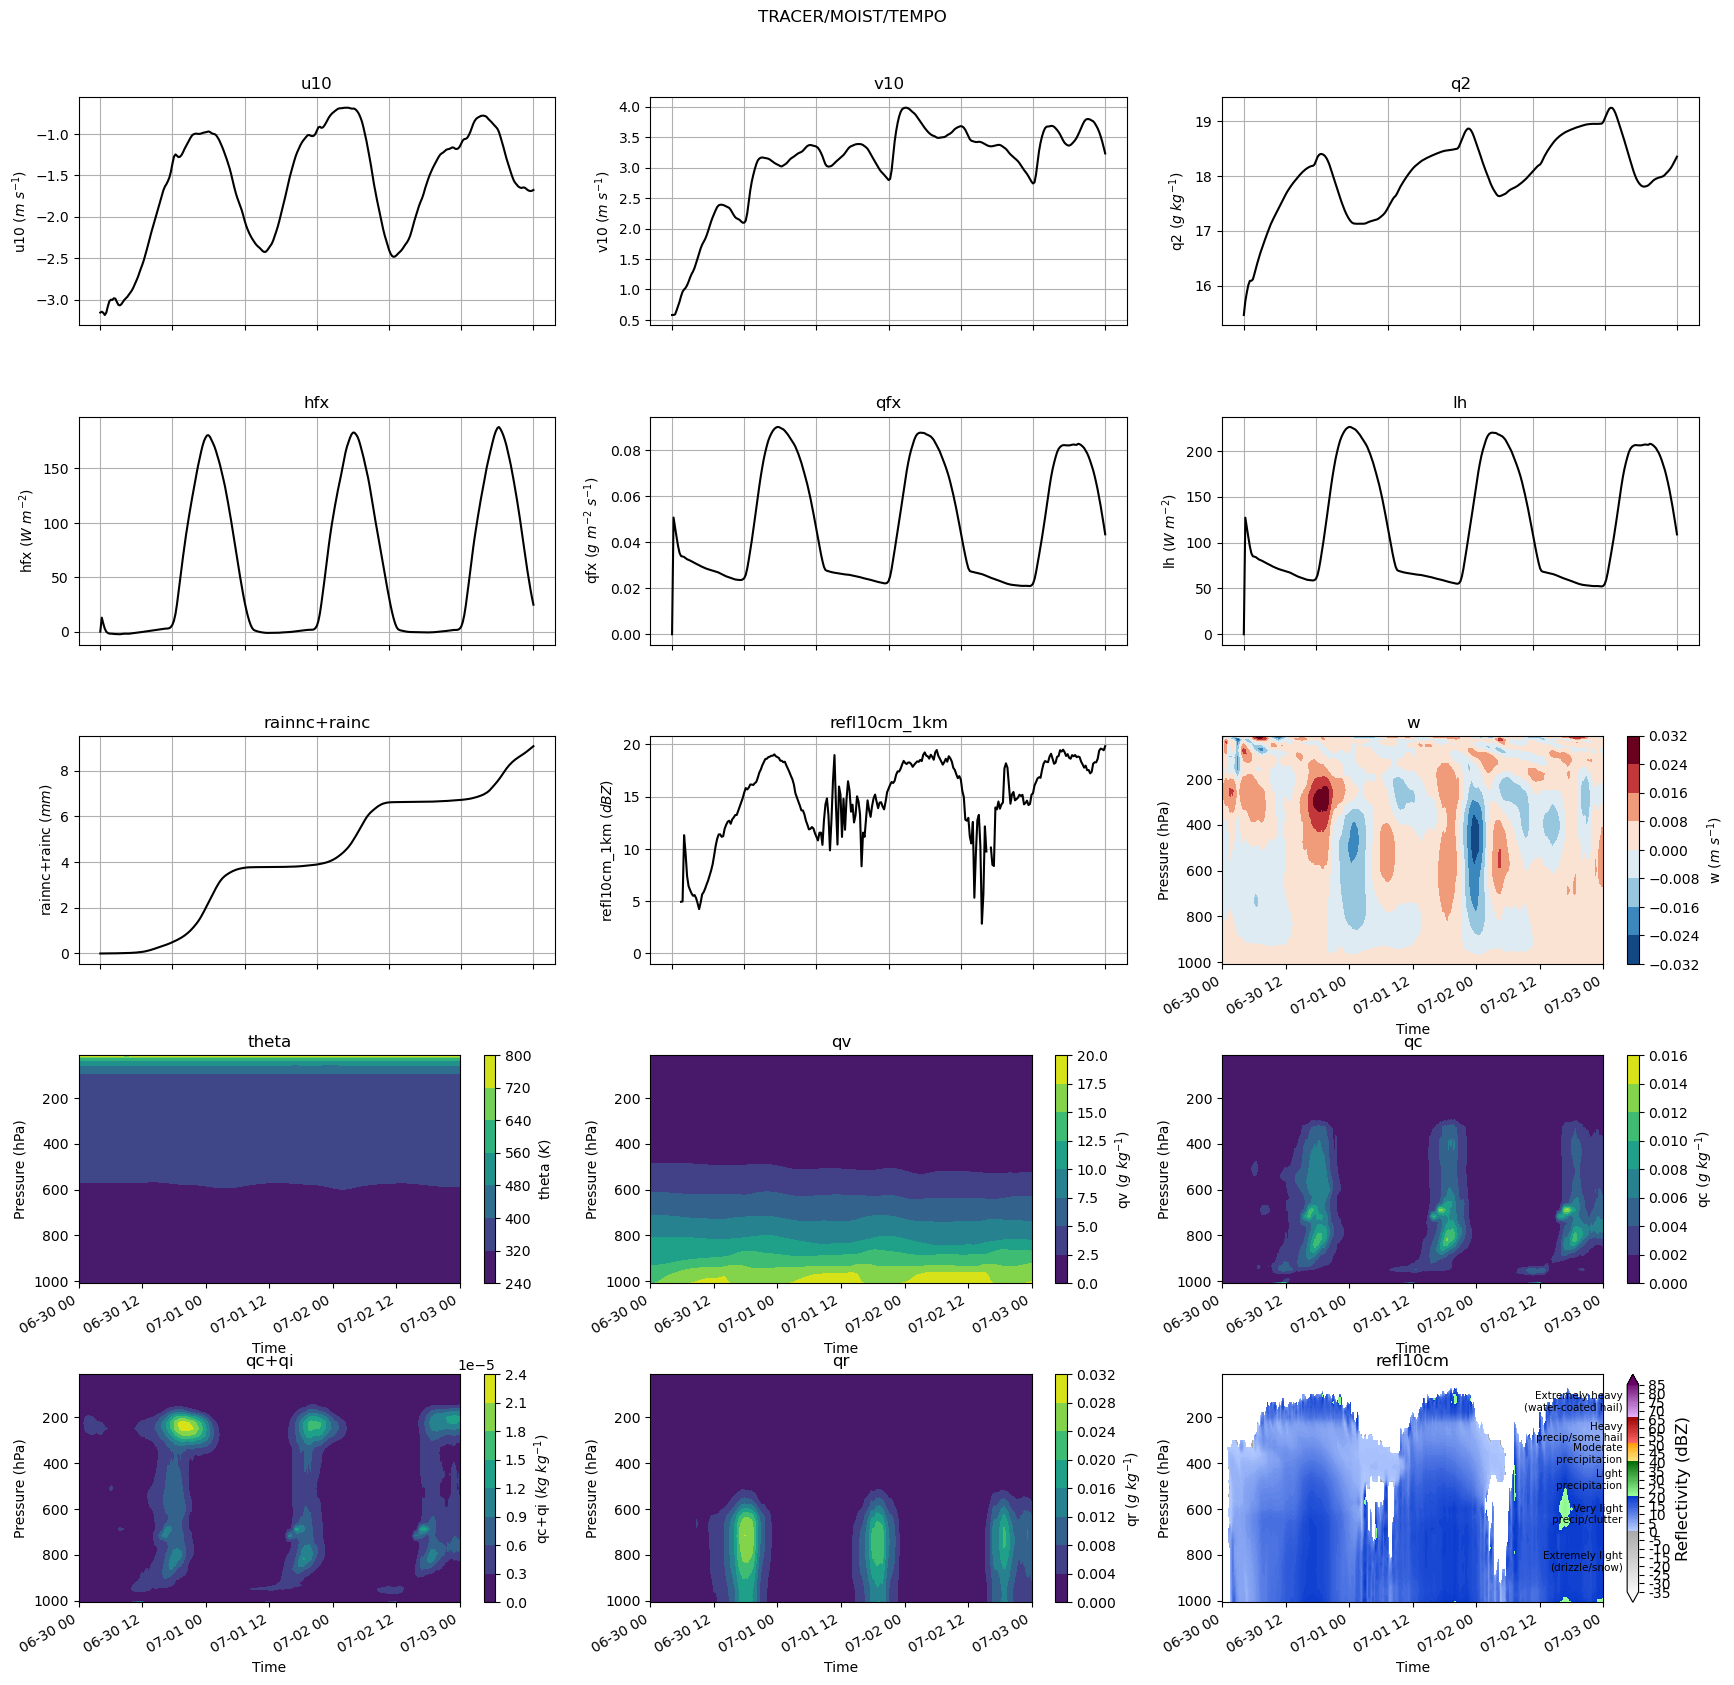

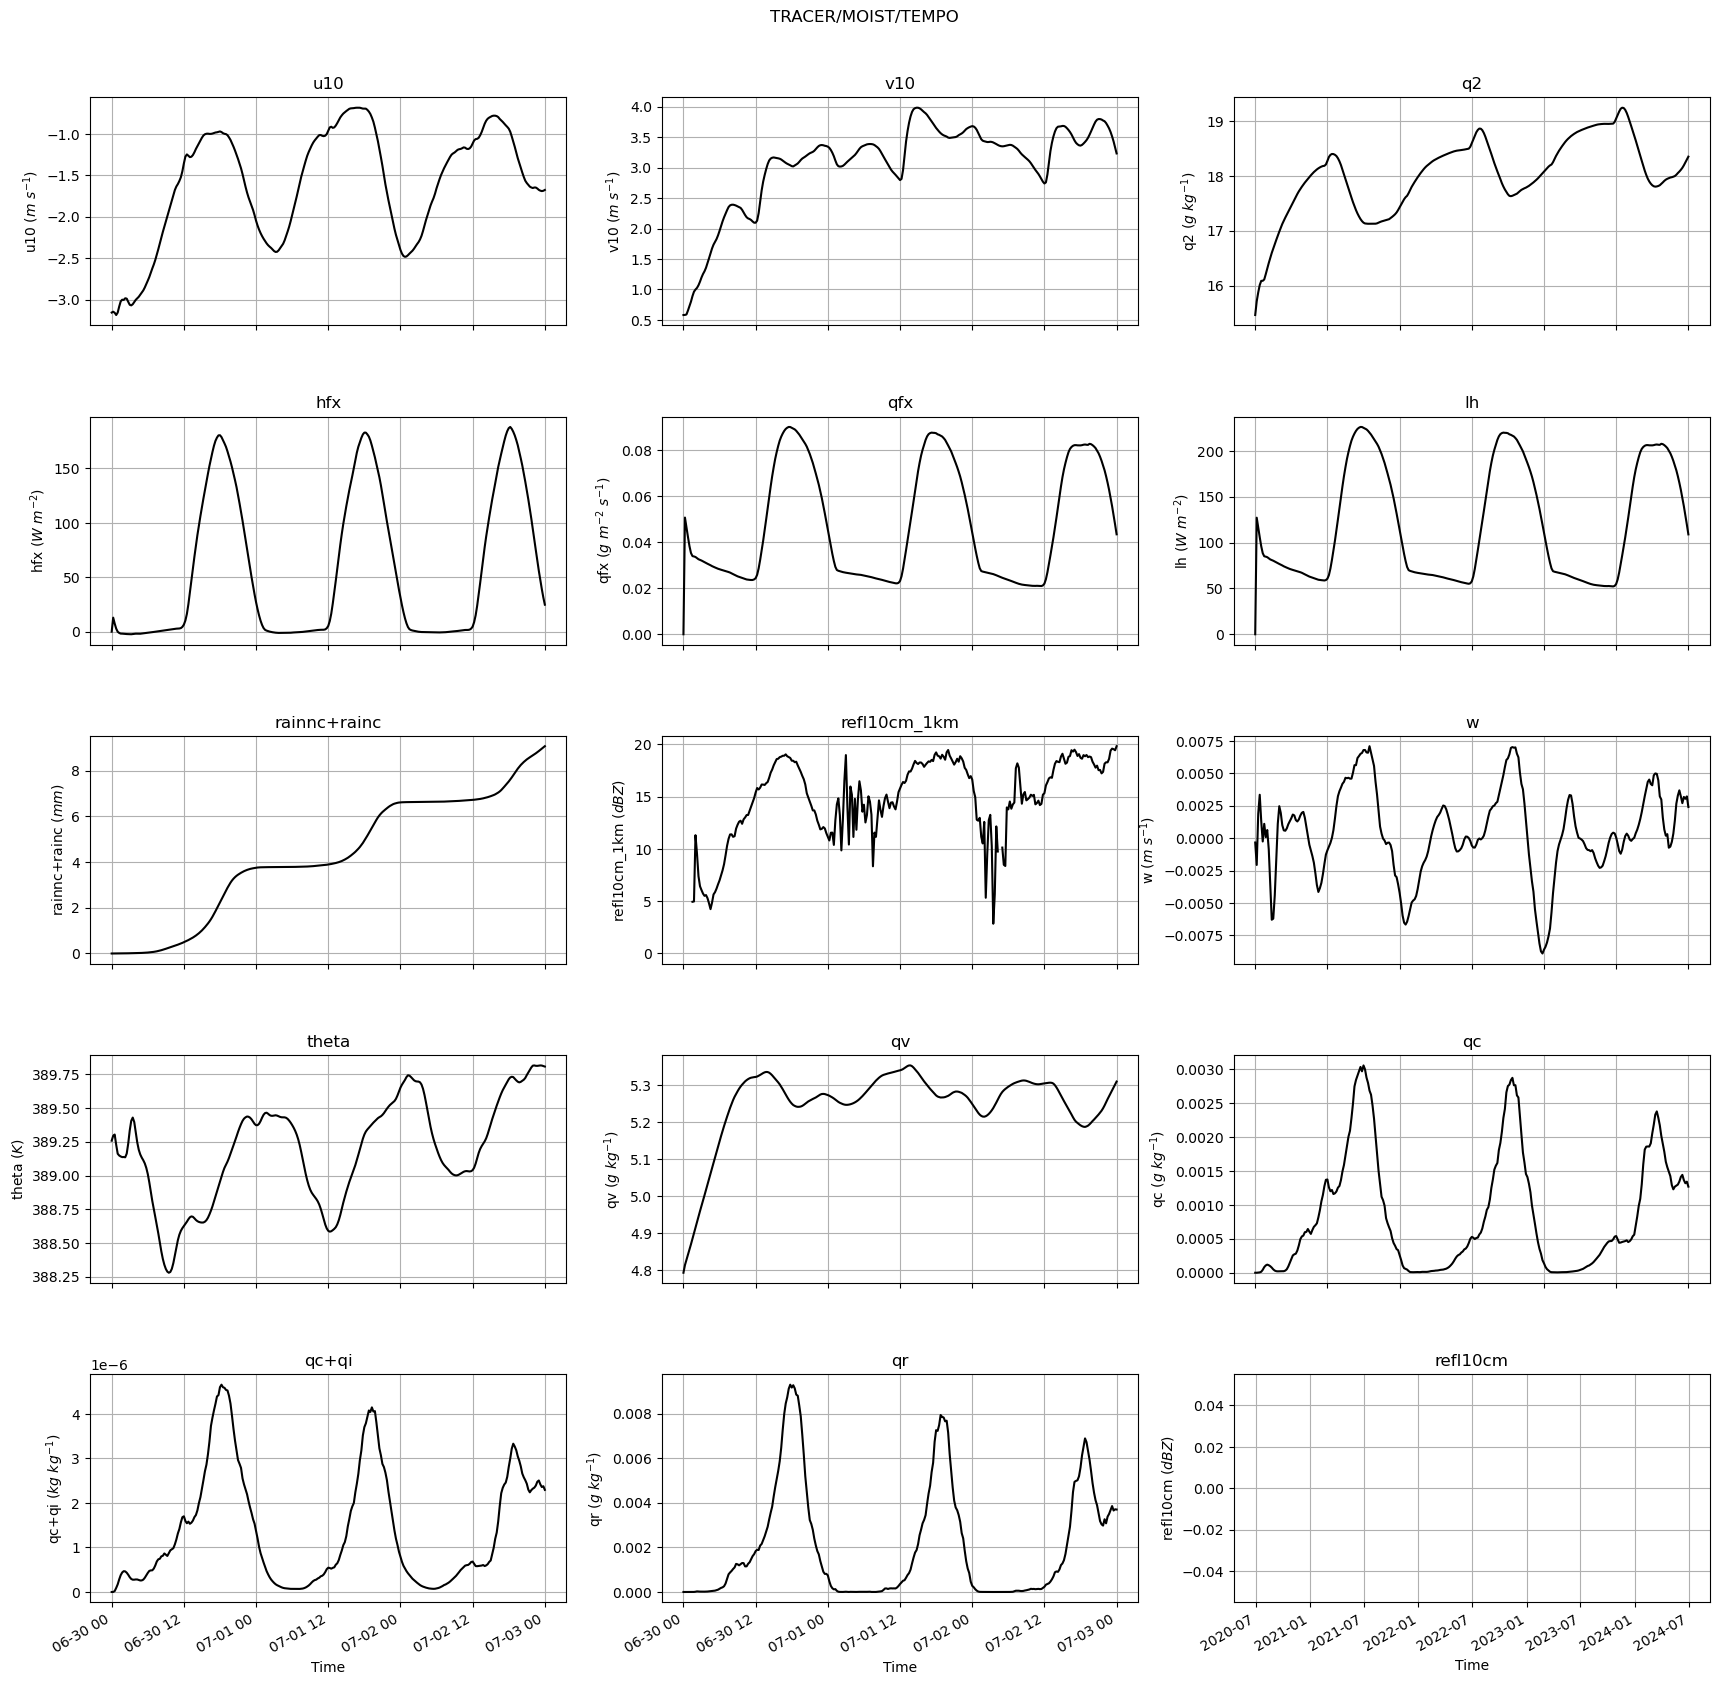

In [50]:
for plottype in ["TZ","T"]:
    fig = MakeCombinedPlot(varNames,plottype=plottype)
    outputFile = os.path.join(outputPlottingDirectory, 
                              f"{ModelData.region}_{ModelData.case}_{ModelData.mpType}", 
                              f"CombinedPlot_{plottype}.pdf")
    os.makedirs(os.path.dirname(outputFile), exist_ok=True)
    fig.savefig(outputFile, dpi=300, bbox_inches="tight")
    print(f"Saved to {outputFile}")

In [ ]:
#plots with both NSSl and TEMPO
#*#*